# Real CT Example: Step-by-Step 3D Attribution

This notebook is the executable companion to the PowerPoint deck. It uses
real 3D CT patches from MSD `Task06_Lung`, a small 3D CNN classifier, and
the real tumour mask as a visual sanity check.

The goal is not to hide the methods behind convenience wrappers. Each
method section follows the same teaching pattern:

1. short text explanation,
2. visible implementation code,
3. intermediate figures for each mathematical step,
4. a final overlay,
5. one overview figure that reuses the heatmaps computed earlier.


## 0. Setup

The notebook kernel should be `Python (gradcam-repro)`. The code below
also makes the local `src/` directory importable when the notebook is
opened from VS Code.


In [1]:
from pathlib import Path  # Work with repository, data, and artifact paths.
import json  # Print cache summaries and score dictionaries.
import os  # Configure process-level environment variables.
import sys  # Add the local src directory to Python's import path.

os.environ.setdefault("XDG_CACHE_HOME", str(Path("/tmp") / "gradcam-repro-cache"))  # Keep font caches writable.
os.environ.setdefault("MPLCONFIGDIR", str(Path("/tmp") / "gradcam-repro-matplotlib"))  # Keep Matplotlib cache writable.

import matplotlib.pyplot as plt  # Draw CT slices and attribution panels.
import torch  # Run the 3D CNN and attribution calculations.
from IPython.display import display  # Display Matplotlib figures in VS Code/Jupyter.

start_path = Path.cwd().resolve()  # Record the notebook working directory.
repo = start_path  # Start by assuming the notebook was opened from the repository root.
for candidate in [start_path, *start_path.parents]:  # Walk upward until the project source package is found.
    if (candidate / "src" / "gradcam_repro").exists():  # Use the source package as the repo marker.
        repo = candidate  # Store the repository root.
        break  # Stop searching.

src_path = repo / "src"  # Compute the source directory.
if str(src_path) not in sys.path:  # Avoid duplicate path entries.
    sys.path.insert(0, str(src_path))  # Prefer local project code over any installed package.

print("repo root:", repo.name)  # Confirm the repository without printing a personal absolute path.


repo root: gradcam-repro


In [2]:
from gradcam_repro.real_ct import DEFAULT_RAW_ROOT  # Default raw MSD Lung directory.
from gradcam_repro.real_ct import RealCtDataset  # Dataset wrapper for cached CT patches.
from gradcam_repro.real_ct import RealCtPreprocessConfig  # Preprocessing configuration.
from gradcam_repro.real_ct import RealCtTrainConfig  # Training configuration.
from gradcam_repro.real_ct import load_cache_summary  # Read cache metadata.
from gradcam_repro.real_ct import load_real_ct_model  # Load the real CT classifier checkpoint.
from gradcam_repro.real_ct import preprocess_msd_lung  # Convert raw MSD Lung files into tensors.
from gradcam_repro.real_ct import score_real_ct_attributions  # Compute mask-based attribution metrics.
from gradcam_repro.real_ct import train_real_ct_model  # Train the real CT classifier when needed.
from gradcam_repro.train import resolve_device  # Select cpu, mps, or cuda.
from gradcam_repro.visualize import DEFAULT_METHODS  # Fixed method order from the PPT.
from gradcam_repro.visualize import overlay_heatmap  # Blend heatmaps with CT slices.
from gradcam_repro.visualize import sample_z  # Select the tumour-centroid axial slice.
from gradcam_repro.visualize import volume_slice  # Extract a 2D slice from a 3D tensor.

## 0.1 Shared Math Primitives

Every method below ends with the same few operations: select the target-class
score, min-max normalize a heatmap to `[0, 1]`, upsample a coarse feature map to
the input grid, or smooth a volume. We define these four small helpers **once**
here, in full view, so each method cell can focus on the method itself rather
than hiding these steps behind an import.

In [3]:
import torch.nn.functional as F  # Trilinear upsampling and 3D convolution for the primitives below.


def score_for_target(logits, target):  # Select the target-class logit y^c that every gradient method differentiates.
    if target is None:  # Fall back to the predicted class when no target is given.
        target_tensor = logits.argmax(dim=1)  # Use the argmax class.
    elif isinstance(target, int):  # Accept a plain integer class index.
        target_tensor = torch.full((logits.shape[0],), target, device=logits.device, dtype=torch.long)  # Broadcast to batch.
    else:  # Otherwise assume a tensor of class indices.
        target_tensor = target.to(device=logits.device, dtype=torch.long)  # Match device and dtype.
    return logits.gather(1, target_tensor.view(-1, 1)).sum()  # Gather the target logits and sum for backward().


def normalize_map(heatmap, eps=1e-8):  # Min-max normalize a 3D heatmap into [0, 1] per batch element.
    flat = heatmap.flatten(1)  # Flatten spatial dims to find per-sample min/max.
    view_shape = (heatmap.shape[0],) + (1,) * (heatmap.ndim - 1)  # Broadcast shape back to the heatmap.
    mins = flat.min(dim=1).values.view(view_shape)  # Per-sample minimum.
    maxs = flat.max(dim=1).values.view(view_shape)  # Per-sample maximum.
    return (heatmap - mins) / (maxs - mins + eps)  # Rescale to [0, 1] with an epsilon guard.


def upsample_to_input(heatmap, x):  # Resize a coarse feature-space map up to the input volume grid.
    return F.interpolate(heatmap, size=x.shape[-3:], mode="trilinear", align_corners=False)  # Trilinear 3D upsample.


def gaussian_blur3d(heatmap, sigma=0.8):  # Smooth a 3D heatmap with a separable Gaussian (used by Integrated Gradients).
    if sigma <= 0:  # A non-positive sigma means no smoothing.
        return heatmap  # Return the input unchanged.
    radius = max(1, int(3 * sigma))  # Kernel half-width covers ~3 sigma.
    coords = torch.arange(-radius, radius + 1, device=heatmap.device, dtype=heatmap.dtype)  # 1D coordinate grid.
    kernel_1d = torch.exp(-(coords**2) / (2 * sigma**2))  # 1D Gaussian weights.
    kernel_1d = kernel_1d / kernel_1d.sum()  # Normalize the 1D kernel.
    kernel_3d = kernel_1d[:, None, None] * kernel_1d[None, :, None] * kernel_1d[None, None, :]  # Outer product into 3D.
    kernel = kernel_3d.view(1, 1, *kernel_3d.shape)  # Shape as [out_ch, in_ch, D, H, W] for conv3d.
    return F.conv3d(heatmap, kernel, padding=radius)  # Convolve with same-size padding.

In [4]:
raw_root = repo / DEFAULT_RAW_ROOT  # Raw MSD Task06_Lung extraction directory.
cache_path = repo / "artifacts" / "real_ct" / "msd_lung_presence_32.pt"  # Preprocessed 32^3 patch cache.
checkpoint_path = repo / "artifacts" / "real_ct" / "real_ct_presence_cnn_32.pt"  # Real CT classifier checkpoint.
score_path = repo / "artifacts" / "real_ct" / "real_ct_scores_32.json"  # Attribution score output path.
device = resolve_device("cpu")  # Use CPU for reproducible classroom execution.
method_order = list(DEFAULT_METHODS)  # Keep the same seven-method order as the PPT.

print("raw data available:", raw_root.exists())  # Confirm raw data availability without printing a local absolute path.
print("cache available:", cache_path.exists())  # Confirm tensor cache availability.
print("checkpoint available:", checkpoint_path.exists())  # Confirm trained model availability.
print("method_order:", method_order)  # Show the order used in final overview plots.


raw data available: True
cache available: True
checkpoint available: True
method_order: ['notgradcam', 'gradcam', 'guided_gradcam', 'layercam', 'occlusion', 'integrated_gradients', 'integrated_gradcam']


## 1. Data Cache and Model

The raw MSD Lung dataset is a segmentation dataset. This project derives
a small classification task from it:

- class `0`: non-tumour CT patch,
- class `1`: tumour-present CT patch.

The tumour mask is kept only for visualization and attribution sanity
checks. Grad-CAM explains the selected class score, not the ground-truth
mask by default.


In [5]:
preprocess_config = RealCtPreprocessConfig(target_shape=(32, 32, 32), task="presence")  # Use the same 32^3 task as the deck.

if cache_path.exists():  # Reuse the cache if it already exists.
    cache_summary = load_cache_summary(cache_path)  # Read cache metadata.
    print(json.dumps(cache_summary, indent=2))  # Display sample counts and split sizes.
elif raw_root.exists():  # Build the cache when raw data is present.
    cache_summary = preprocess_msd_lung(raw_root, cache_path, config=preprocess_config)  # Convert NIfTI files to tensors.
    print(json.dumps(cache_summary, indent=2))  # Display preprocessing metadata.
else:  # Stop cleanly when raw data is missing.
    raise FileNotFoundError(f"Missing MSD Task06_Lung under {DEFAULT_RAW_ROOT}")  # Make the missing dependency explicit.


{
  "schema": "gradcam-repro.real-ct-msd-lung.v2",
  "n_cases": 252,
  "image_shape": [
    1,
    32,
    32,
    32
  ],
  "label_counts": {
    "0": 126,
    "1": 126
  },
  "splits": {
    "train": 176,
    "val": 38,
    "test": 38
  },
  "source": {
    "dataset": "MSD Task06_Lung",
    "raw_root": "data/msd/Task06_Lung",
    "classification_label": "0=non-tumour CT patch, 1=tumour-present CT patch",
    "segmentation_mask": "MSD lung tumour mask cropped into positive patches",
    "task": "tumour_presence_patch"
  }
}


In [6]:
train_config = RealCtTrainConfig(batch_size=16, epochs=12, early_stop_acc=0.90, lr=3e-3)  # Training settings used for the current deck.

if checkpoint_path.exists():  # Reuse the existing checkpoint if present.
    print("checkpoint exists:", checkpoint_path.relative_to(repo))  # Print a repo-relative checkpoint path.
elif cache_path.exists():  # Train only after preprocessing has completed.
    train_result = train_real_ct_model(cache_path, checkpoint_path, config=train_config, device_name="cpu")  # Train the CT classifier.
    print(json.dumps(train_result, indent=2))  # Display training and test metrics.
else:  # This branch should not run after the previous cell succeeds.
    raise FileNotFoundError("Missing cache: artifacts/real_ct/msd_lung_presence_32.pt")  # Fail explicitly.

model = load_real_ct_model(checkpoint_path, device)  # Load the real CT classifier.
model.eval()  # Put the model in inference mode immediately after loading.
dataset = RealCtDataset(cache_path, split="test", positive_only=True)  # Use positive test patches for attribution-mask comparison.
sample = dataset[0]  # Select one tumour-present CT patch for the step-by-step walkthrough.
z_index = sample_z(sample)  # Select the tumour-centroid axial slice.
image = sample["image"].unsqueeze(0).to(device)  # Add a batch dimension: [1, 1, D, H, W].
target = sample["label"].view(1).to(device)  # Target class tensor, normally class 1.
target_class = int(target.item())  # Convert the selected target to a Python integer for indexing and printing.

with torch.no_grad():  # Inspect what the classifier predicts for this patch.
    logits_sample = model(image)  # Forward the selected CT patch.
    probs_sample = logits_sample.softmax(dim=1)  # Convert logits to class probabilities.

heatmaps = {}  # Store method outputs so the final overview can reuse earlier calculations.
print("case_id:", sample["case_id"])  # Show the source case id.
print("pred_class:", int(probs_sample.argmax(dim=1).item()))  # Show the model-predicted class.
print("target_class:", target_class)  # Show the class score that attribution methods will explain.
print("target_prob:", float(probs_sample[0, target_class].item()))  # Show confidence for the explained class.
print("image:", tuple(image.shape), "target slice z:", z_index)  # Show tensor shape and display slice.


checkpoint exists: artifacts/real_ct/real_ct_presence_cnn_32.pt
case_id: lung_038_pos1
pred_class: 1
target_class: 1
target_prob: 0.8782122731208801
image: (1, 1, 32, 32, 32) target slice z: 19


## 2. Input Volume and Tumour Mask

We first inspect the axial slice used throughout the notebook. All
methods below compute 3D heatmaps, but we render one representative
slice that intersects the tumour mask.


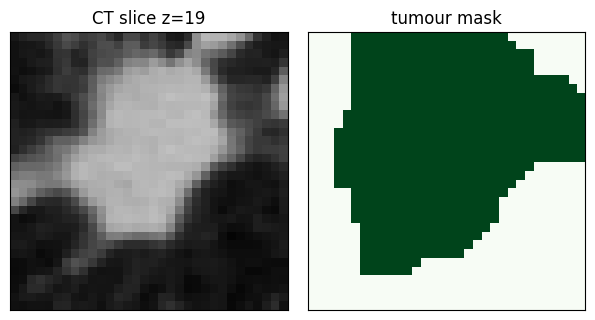

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(6.0, 3.0))  # Create side-by-side CT and mask panels.
axes[0].imshow(volume_slice(sample["image"], z_index), cmap="gray", vmin=0, vmax=1)  # Draw the CT slice.
axes[0].set_title(f"CT slice z={z_index}")  # Label the CT panel.
axes[1].imshow(volume_slice(sample["mask"], z_index), cmap="Greens", vmin=0, vmax=1)  # Draw the tumour mask.
axes[1].set_title("tumour mask")  # Label the mask panel.
for axis in axes:  # Remove visual clutter from both panels.
    axis.set_xticks([])  # Hide x ticks.
    axis.set_yticks([])  # Hide y ticks.
fig.tight_layout(pad=0.35)  # Reduce whitespace.
display(fig)  # Show the figure in the notebook.
plt.close(fig)  # Close the Matplotlib handle after display.


## 3. Method 01: notGradCAM / Activation-Only Map

This is the control baseline. It ignores the target class and asks only:
which stage-2 feature channels are active?

Formula:

$$
M(x) = \operatorname{Up}\left(\frac{1}{K}\sum_k A^k(x)\right)
$$


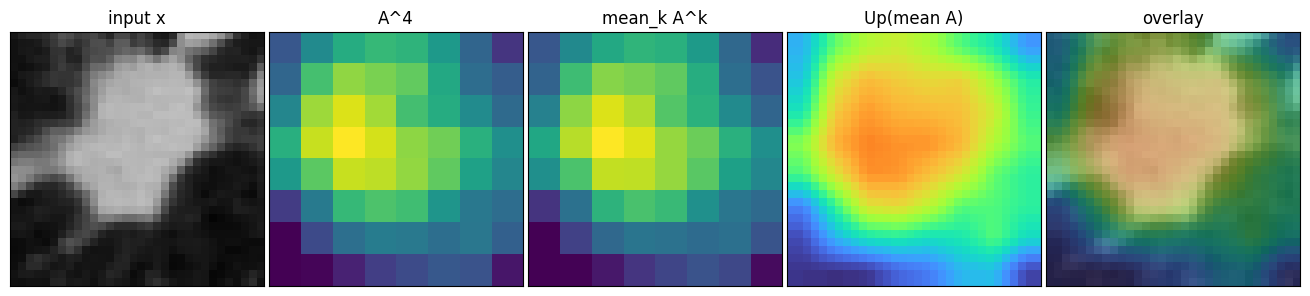

In [8]:
with torch.no_grad():  # No gradient is needed for activation-only maps.
    logits_ng, features_ng = model(image, return_features=True)  # Forward the CT patch and keep intermediate feature volumes.
    A_ng = features_ng["stage2"]  # Read the tap-layer activation tensor: [B, K, D, H, W].
    mean_activation = A_ng.mean(dim=1, keepdim=True)  # Average channels: (1/K) sum_k A^k.
    notgradcam_heat = normalize_map(upsample_to_input(mean_activation, image))  # Upsample and normalize to input size.

heatmaps["notGradCAM"] = notgradcam_heat.detach().cpu()  # Store the output for the final overview.
channel_index = int(A_ng.flatten(2).mean(dim=2).squeeze(0).argmax().item())  # Choose the most active channel for display.
feature_z = round(z_index * (A_ng.shape[-3] - 1) / (image.shape[-3] - 1))  # Map input z to feature z.

fig, axes = plt.subplots(1, 5, figsize=(13.0, 3.0))  # Show each step from input to overlay.
axes[0].imshow(volume_slice(sample["image"], z_index), cmap="gray", vmin=0, vmax=1)  # Input CT.
axes[0].set_title("input x")  # Label input.
A_slice = volume_slice(A_ng[0, channel_index], feature_z)  # Display one representative feature channel.
axes[1].imshow(A_slice, cmap="viridis")  # Draw A^k.
axes[1].set_title(f"A^{channel_index}")  # Label activation channel.
axes[2].imshow(volume_slice(mean_activation, feature_z), cmap="viridis")  # Draw channel average before upsampling.
axes[2].set_title("mean_k A^k")  # Label channel average.
axes[3].imshow(volume_slice(notgradcam_heat.cpu(), z_index), cmap="turbo", vmin=0, vmax=1)  # Draw final heatmap.
axes[3].set_title("Up(mean A)")  # Label heatmap.
axes[4].imshow(overlay_heatmap(sample["image"], notgradcam_heat.cpu(), z_index))  # Draw heatmap over CT.
axes[4].set_title("overlay")  # Label overlay.
for axis in axes:  # Clean all panels.
    axis.set_xticks([])  # Hide x ticks.
    axis.set_yticks([])  # Hide y ticks.
fig.tight_layout(pad=0.35)  # Reduce whitespace.
display(fig)  # Display the runtime-generated figure.
plt.close(fig)  # Close the Matplotlib handle.


### All 16 stage2 channels

`notGradCAM` collapses the tap layer with equal weights: $M(x) = \operatorname{Up}(\frac{1}{K}\sum_k A^k)$.
The grid below shows every channel $A^0 \dots A^{15}$ at the display slice, on a shared
color scale. Some channels light up on the tumour, others on unrelated structure or
barely at all — averaging them with the same $1/K$ weight is exactly why this control
map is not class-specific.

In [ ]:
# notGradCAM averages all 16 stage2 channels with equal weight 1/K. Before trusting
# that average, look at the raw channels A^0 .. A^15 at the display slice.
K = A_ng.shape[1]                                                       # number of tap-layer channels (16)
feat_z = round(z_index * (A_ng.shape[-3] - 1) / (image.shape[-3] - 1))  # map input z to the feature-map z
panel = A_ng[0, :, feat_z].detach().cpu()                               # every channel at that slice: [K, H, W]
vmin, vmax = float(panel.min()), float(panel.max())                     # shared color scale so channels compare fairly

cols = 4                                                                # 4x4 grid holds all 16 channels
rows = (K + cols - 1) // cols                                           # rows needed for K channels
fig, axes = plt.subplots(rows, cols, figsize=(7.5, 7.8))                # one panel per channel
for k in range(K):                                                      # draw each activation channel
    ax = axes[k // cols][k % cols]                                      # locate its grid cell
    ax.imshow(panel[k], cmap="viridis", vmin=vmin, vmax=vmax)           # A^k on the shared color scale
    ax.set_title(f"A^{k}", fontsize=9)                                  # label the channel index
    ax.set_xticks([])                                                   # hide x ticks
    ax.set_yticks([])                                                   # hide y ticks
for k in range(K, rows * cols):                                         # blank any unused grid cells
    axes[k // cols][k % cols].axis("off")                               # turn the empty panel off
fig.suptitle(f"stage2 activation: all {K} channels A^0..A^{K - 1} (feature slice z={feat_z})", fontsize=10)  # grid title
fig.tight_layout()                                                      # reduce whitespace
display(fig)                                                            # show the channel grid
plt.close(fig)                                                          # close the Matplotlib handle

## 4. Method 02: Grad-CAM

Grad-CAM makes the map class-specific by weighting each feature channel
with the spatial mean of the target-class gradient.

Formula:

$$
\alpha_k^c = \frac{1}{Z}\sum_d\sum_i\sum_j
\frac{\partial y^c}{\partial A^k_{dij}},
\quad
L^c = \operatorname{ReLU}\left(\sum_k \alpha_k^c A^k\right)
$$


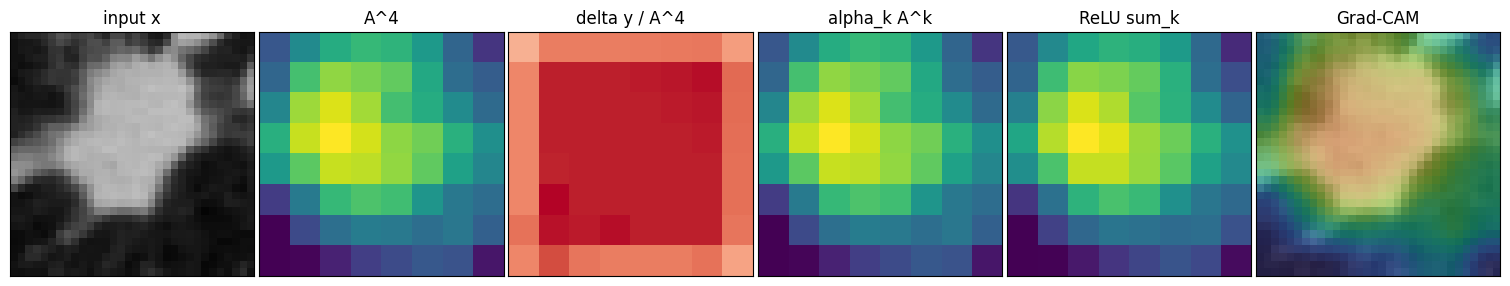

In [9]:
model.zero_grad(set_to_none=True)  # Clear old gradients before the backward pass.
logits_gc, features_gc = model(image, return_features=True)  # Forward pass with feature retention.
A_gc = features_gc["stage2"]  # Tap-layer activation tensor.
A_gc.retain_grad()  # Ask PyTorch to keep gradients for this non-leaf tensor.
y_c = score_for_target(logits_gc, target)  # Select the target class logit y^c.
y_c.backward()  # Backpropagate y^c to A.
delta_y_gc = A_gc.grad  # This is delta y^c / delta A^k at every 3D position.
alpha_gc = delta_y_gc.mean(dim=(2, 3, 4), keepdim=True)  # Spatially average gradients into one weight per channel.
weighted_A_gc = alpha_gc * A_gc  # Weight each activation channel by its Grad-CAM alpha.
summed_gc = weighted_A_gc.sum(dim=1, keepdim=True).clamp_min(0)  # Sum channels and apply ReLU.
gradcam_heat = normalize_map(upsample_to_input(summed_gc, image))  # Upsample to the 32^3 input grid.

heatmaps["Grad-CAM"] = gradcam_heat.detach().cpu()  # Store the output for the final overview.
channel_index = int(weighted_A_gc.flatten(2).mean(dim=2).abs().squeeze(0).argmax().item())  # Pick a visible channel.
feature_z = round(z_index * (A_gc.shape[-3] - 1) / (image.shape[-3] - 1))  # Map input z to feature z.

grad_slice = volume_slice(delta_y_gc[0, channel_index], feature_z)  # Signed target gradient slice.
grad_limit = float(grad_slice.detach().abs().max().clamp_min(1e-8).item())  # Symmetric color limit for signed gradients.

fig, axes = plt.subplots(1, 6, figsize=(15.0, 3.0))  # Show the Grad-CAM calculation chain.
axes[0].imshow(volume_slice(sample["image"], z_index), cmap="gray", vmin=0, vmax=1)  # Input CT.
axes[0].set_title("input x")  # Label input.
axes[1].imshow(volume_slice(A_gc[0, channel_index], feature_z).detach().cpu(), cmap="viridis")  # Feature channel.
axes[1].set_title(f"A^{channel_index}")  # Label A^k.
axes[2].imshow(grad_slice.detach().cpu(), cmap="coolwarm", vmin=-grad_limit, vmax=grad_limit)  # Signed delta y map.
axes[2].set_title(f"delta y / A^{channel_index}")  # Label gradient map.
axes[3].imshow(volume_slice(weighted_A_gc[0, channel_index], feature_z).detach().cpu(), cmap="viridis")  # Alpha-weighted feature.
axes[3].set_title("alpha_k A^k")  # Label weighted feature.
axes[4].imshow(volume_slice(summed_gc.detach().cpu(), feature_z), cmap="viridis")  # Channel sum before upsampling.
axes[4].set_title("ReLU sum_k")  # Label summed map.
axes[5].imshow(overlay_heatmap(sample["image"], gradcam_heat.cpu(), z_index))  # Final overlay.
axes[5].set_title("Grad-CAM")  # Label final map.
for axis in axes:  # Clean all panels.
    axis.set_xticks([])  # Hide x ticks.
    axis.set_yticks([])  # Hide y ticks.
fig.tight_layout(pad=0.35)  # Reduce whitespace.
display(fig)  # Display the figure.
plt.close(fig)  # Close the figure handle.


## 5. Method 03: Guided Grad-CAM

Guided Grad-CAM multiplies high-frequency guided backpropagation by the
coarse Grad-CAM class mask. The implementation detail is important:
Guided Backprop can look sharp even when it is not faithful, so this
method is mainly useful for visual detail, not as a standalone proof.

The core of Guided Backprop is the modified ReLU backward rule: it keeps a
gradient only where the gradient itself is positive **and** the forward
activation was positive. We implement it inline as the `guided_relu_hooks`
context manager, which installs Guided ReLU hooks only inside its `with`
block and removes them on exit, so later gradient methods use ordinary
backpropagation.

Formula:

$$
L = |\operatorname{GuidedBP}(x,c) \odot \operatorname{Up}(G^c)|
$$

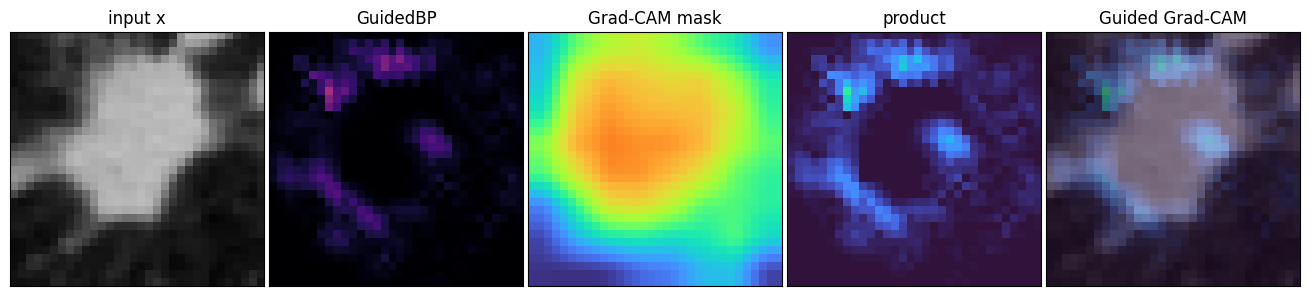

In [10]:
from contextlib import contextmanager  # Install guided ReLU hooks only for the duration of one backward pass.


@contextmanager  # Guided Backprop replaces every ReLU's backward rule for the length of this block.
def guided_relu_hooks(model):  # Yield with guided ReLU hooks installed, then remove them on exit.
    activations = {}  # Remember each ReLU's forward output so the backward hook can gate on it.
    handles = []  # Track hook handles so we can remove them afterward.

    def forward_hook(module, _inputs, output):  # Cache the forward activation of each ReLU.
        activations[module] = output  # Store output for the matching backward pass.

    def backward_hook(module, _grad_input, grad_output):  # Guided ReLU: keep positive grads at positive activations.
        grad = grad_output[0]  # Incoming gradient from the layer above.
        if grad is None:  # Guard against a missing gradient.
            raise RuntimeError("Guided ReLU hook received no gradient")  # Fail loudly instead of silently.
        activation = activations[module]  # The cached forward activation.
        guided_grad = grad.clamp_min(0) * (activation > 0).to(dtype=grad.dtype)  # Zero out negative grads and dead units.
        return (guided_grad,)  # Replace the gradient flowing further back.

    for module in model.modules():  # Attach hooks to every ReLU in the network.
        if isinstance(module, torch.nn.ReLU):  # Only ReLU layers get guided treatment.
            handles.append(module.register_forward_hook(forward_hook))  # Record forward activations.
            handles.append(module.register_full_backward_hook(backward_hook))  # Rewrite the backward rule.
    try:  # Hand control back to the caller with hooks live.
        yield  # Run the caller's forward/backward here.
    finally:  # Always clean up so later methods use ordinary backprop.
        for handle in handles:  # Remove every hook we installed.
            handle.remove()  # Detach the hook.


model.zero_grad(set_to_none=True)  # Clear old gradients before the guided pass.
x_req = image.detach().clone().requires_grad_(True)  # Guided Backprop needs the gradient w.r.t. the input voxels.
with guided_relu_hooks(model):  # Only inside this block do ReLUs use the guided backward rule.
    logits_guided = model(x_req)  # Forward the CT patch with guided hooks active.
    score_for_target(logits_guided, target).backward()  # Backpropagate the target logit to the input.
if x_req.grad is None:  # The guided pass must produce an input gradient.
    raise RuntimeError("Guided backprop did not produce an input gradient")  # Fail loudly if it did not.
guided_raw = x_req.grad  # Raw guided-backprop input gradient: [B, 1, D, H, W].

guided_abs = guided_raw.abs().sum(dim=1, keepdim=True)  # Collapse input channels into one saliency volume.
guided_norm = normalize_map(guided_abs)  # Normalize guided backprop for display.
guided_product = guided_raw * gradcam_heat.to(device)  # Gate high-frequency guided gradients by the Grad-CAM mask.
guided_gradcam_heat = normalize_map(guided_product.abs().sum(dim=1, keepdim=True))  # Collapse and normalize the product.

heatmaps["Guided Grad-CAM"] = guided_gradcam_heat.detach().cpu()  # Store the output for the final overview.

fig, axes = plt.subplots(1, 5, figsize=(13.0, 3.0))  # Show the Guided Grad-CAM chain.
axes[0].imshow(volume_slice(sample["image"], z_index), cmap="gray", vmin=0, vmax=1)  # Input CT.
axes[0].set_title("input x")  # Label input.
axes[1].imshow(volume_slice(guided_norm.cpu(), z_index), cmap="magma", vmin=0, vmax=1)  # Guided BP.
axes[1].set_title("GuidedBP")  # Label guided backprop.
axes[2].imshow(volume_slice(gradcam_heat.cpu(), z_index), cmap="turbo", vmin=0, vmax=1)  # Grad-CAM mask.
axes[2].set_title("Grad-CAM mask")  # Label class mask.
axes[3].imshow(volume_slice(guided_gradcam_heat.cpu(), z_index), cmap="turbo", vmin=0, vmax=1)  # Product heatmap.
axes[3].set_title("product")  # Label product.
axes[4].imshow(overlay_heatmap(sample["image"], guided_gradcam_heat.cpu(), z_index))  # Final overlay.
axes[4].set_title("Guided Grad-CAM")  # Label final map.
for axis in axes:  # Clean all panels.
    axis.set_xticks([])  # Hide x ticks.
    axis.set_yticks([])  # Hide y ticks.
fig.tight_layout(pad=0.35)  # Reduce whitespace.
display(fig)  # Display the figure.
plt.close(fig)  # Close the figure handle.

## 6. Method 04: LayerCAM

LayerCAM keeps the gradient local. Instead of compressing a whole 3D
gradient map into one channel weight, it uses positive gradients at each
feature location.

Formula:

$$
\delta_k^c = \frac{\partial y^c}{\partial A^k},
\quad
L^c = \sum_k \operatorname{ReLU}(\delta_k^c) \odot A^k
$$


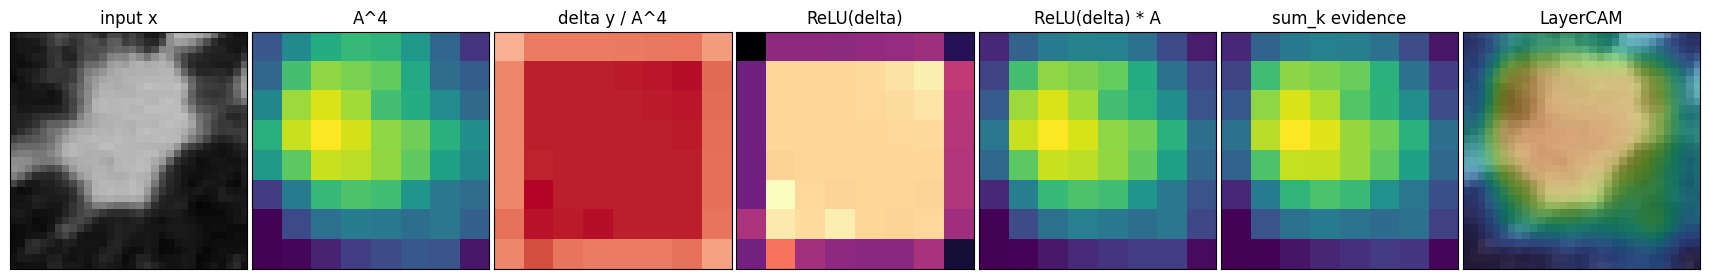

In [11]:
model.zero_grad(set_to_none=True)  # Clear old gradients.
logits_lc, features_lc = model(image, return_features=True)  # Forward pass with feature retention.
A_lc = features_lc["stage2"]  # Tap-layer activation tensor.
A_lc.retain_grad()  # Retain gradients on the feature tensor.
score_for_target(logits_lc, target).backward()  # Backpropagate the target logit.
delta_y_lc = A_lc.grad  # Signed local gradient map: delta y^c / delta A^k.
positive_delta_lc = delta_y_lc.clamp_min(0)  # Keep only positive local evidence.
local_product_lc = positive_delta_lc * A_lc  # Weight activations at every spatial location.
summed_lc = local_product_lc.sum(dim=1, keepdim=True).clamp_min(0)  # Sum channels into one feature-volume map.
layercam_heat = normalize_map(upsample_to_input(summed_lc, image))  # Upsample to input volume size.

heatmaps["LayerCAM"] = layercam_heat.detach().cpu()  # Store the output for the final overview.
channel_index = int(local_product_lc.flatten(2).mean(dim=2).squeeze(0).argmax().item())  # Pick a visible channel.
feature_z = round(z_index * (A_lc.shape[-3] - 1) / (image.shape[-3] - 1))  # Map input z to feature z.
delta_slice = volume_slice(delta_y_lc[0, channel_index], feature_z)  # Signed delta-y slice.
delta_limit = float(delta_slice.detach().abs().max().clamp_min(1e-8).item())  # Symmetric color limit.

fig, axes = plt.subplots(1, 7, figsize=(17.0, 3.0))  # Show the LayerCAM chain including delta y.
axes[0].imshow(volume_slice(sample["image"], z_index), cmap="gray", vmin=0, vmax=1)  # Input CT.
axes[0].set_title("input x")  # Label input.
axes[1].imshow(volume_slice(A_lc[0, channel_index], feature_z).detach().cpu(), cmap="viridis")  # Feature channel.
axes[1].set_title(f"A^{channel_index}")  # Label feature channel.
axes[2].imshow(delta_slice.detach().cpu(), cmap="coolwarm", vmin=-delta_limit, vmax=delta_limit)  # Signed delta-y gradient.
axes[2].set_title(f"delta y / A^{channel_index}")  # Label signed local gradient.
axes[3].imshow(volume_slice(positive_delta_lc[0, channel_index], feature_z).detach().cpu(), cmap="magma")  # Positive gradients.
axes[3].set_title("ReLU(delta)")  # Label positive gradient.
axes[4].imshow(volume_slice(local_product_lc[0, channel_index], feature_z).detach().cpu(), cmap="viridis")  # Local product.
axes[4].set_title("ReLU(delta) * A")  # Label product.
axes[5].imshow(volume_slice(summed_lc.detach().cpu(), feature_z), cmap="viridis")  # Summed evidence.
axes[5].set_title("sum_k evidence")  # Label sum.
axes[6].imshow(overlay_heatmap(sample["image"], layercam_heat.cpu(), z_index))  # Final overlay.
axes[6].set_title("LayerCAM")  # Label final map.
for axis in axes:  # Clean all panels.
    axis.set_xticks([])  # Hide x ticks.
    axis.set_yticks([])  # Hide y ticks.
fig.tight_layout(pad=0.35)  # Reduce whitespace.
display(fig)  # Display the figure.
plt.close(fig)  # Close the figure handle.


## 7. Method 05: Occlusion Sensitivity

Occlusion removes one cube at a time and measures whether the target
class probability drops. This is slower than gradients, but it directly
asks a causal question: what happens when this region is hidden?

Formula:

$$
H(p) = F_c(x) - F_c(x \odot (1 - M_{p,s}) + \mu(x)M_{p,s})
$$


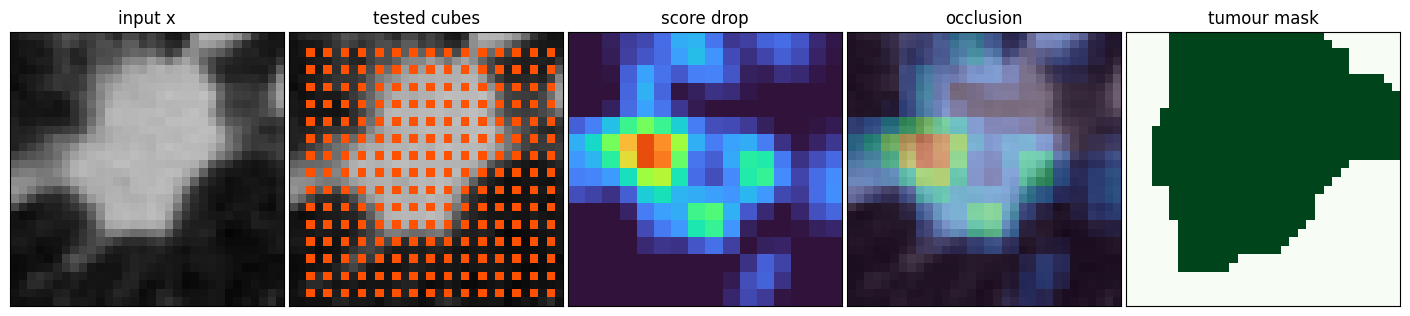

In [12]:
mask_size = 4  # Cube edge length in voxels.
stride = 2  # Sliding stride; smaller is denser and slower.
fill_value = float(image.mean().item())  # Use the per-volume mean as the replacement value.
with torch.no_grad():  # Occlusion requires forward passes only.
    base_prob = model(image).softmax(dim=1).gather(1, target.view(-1, 1)).view(-1)  # Baseline target probability.

batch, _, depth, height, width = image.shape  # Read volume shape.
occlusion_heat = torch.zeros((batch, 1, depth, height, width), device=device)  # Accumulate positive score drops.
occlusion_counts = torch.zeros_like(occlusion_heat)  # Count how many cubes cover each voxel.
cube_positions = [  # Enumerate all tested cube positions.
    (z0, y0, x0)
    for z0 in range(0, depth - mask_size + 1, stride)
    for y0 in range(0, height - mask_size + 1, stride)
    for x0 in range(0, width - mask_size + 1, stride)
]

for start in range(0, len(cube_positions), 128):  # Batch cube tests to keep runtime reasonable.
    chunk = cube_positions[start : start + 128]  # Select a batch of cube positions.
    occluded_batch = image.repeat_interleave(len(chunk), dim=0).clone()  # Make one copy per cube.
    for j, (z0, y0, x0) in enumerate(chunk):  # Apply each cube mask.
        occluded_batch[j, :, z0 : z0 + mask_size, y0 : y0 + mask_size, x0 : x0 + mask_size] = fill_value  # Mean-fill the cube.
    with torch.no_grad():  # Forward all occluded volumes.
        occluded_probs = model(occluded_batch).softmax(dim=1)[:, int(target.item())]  # Target probabilities after masking.
    drops = (base_prob[0] - occluded_probs).clamp_min(0)  # Keep only positive target-score drops.
    for j, (z0, y0, x0) in enumerate(chunk):  # Write each drop back to its cube region.
        occlusion_heat[:, :, z0 : z0 + mask_size, y0 : y0 + mask_size, x0 : x0 + mask_size] += drops[j]  # Accumulate drop.
        occlusion_counts[:, :, z0 : z0 + mask_size, y0 : y0 + mask_size, x0 : x0 + mask_size] += 1  # Accumulate coverage.

occlusion_heat = normalize_map(occlusion_heat / occlusion_counts.clamp_min(1))  # Average overlaps and normalize.
heatmaps["Occlusion"] = occlusion_heat.detach().cpu()  # Store the output for the final overview.

grid_slice = volume_slice(sample["image"], z_index).float().cpu()  # Start from the CT slice.
grid_rgb = grid_slice.unsqueeze(-1).repeat(1, 1, 3)  # Convert grayscale to RGB for orange markers.
for z0, y0, x0 in cube_positions:  # Draw tested cube centers on the displayed slice.
    if z0 <= z_index < z0 + mask_size:  # Only mark cubes intersecting the rendered slice.
        grid_rgb[min(height - 1, y0 + mask_size // 2), min(width - 1, x0 + mask_size // 2)] = torch.tensor([1.0, 0.32, 0.0])  # Orange center marker.

fig, axes = plt.subplots(1, 5, figsize=(14.0, 3.0))  # Show the occlusion workflow.
axes[0].imshow(volume_slice(sample["image"], z_index), cmap="gray", vmin=0, vmax=1)  # Input CT.
axes[0].set_title("input x")  # Label input.
axes[1].imshow(grid_rgb)  # Full tested grid on this slice.
axes[1].set_title("tested cubes")  # Label grid.
axes[2].imshow(volume_slice(occlusion_heat.cpu(), z_index), cmap="turbo", vmin=0, vmax=1)  # Score-drop heatmap.
axes[2].set_title("score drop")  # Label heatmap.
axes[3].imshow(overlay_heatmap(sample["image"], occlusion_heat.cpu(), z_index))  # Final overlay.
axes[3].set_title("occlusion")  # Label overlay.
axes[4].imshow(volume_slice(sample["mask"], z_index), cmap="Greens", vmin=0, vmax=1)  # Tumour mask.
axes[4].set_title("tumour mask")  # Label mask.
for axis in axes:  # Clean all panels.
    axis.set_xticks([])  # Hide x ticks.
    axis.set_yticks([])  # Hide y ticks.
fig.tight_layout(pad=0.35)  # Reduce whitespace.
display(fig)  # Display the figure.
plt.close(fig)  # Close the figure handle.


## 8. Method 06: Integrated Gradients

Integrated Gradients avoids relying on one saturated gradient snapshot.
It averages input gradients along a path from a baseline volume to the
real CT patch. The formula is signed attribution; the figure below shows
absolute attribution magnitude so it can be overlaid as one heatmap.

Formula:

$$
IG_i(x) = (x_i - x'_i)\int_0^1
\frac{\partial F_c(x' + \alpha(x - x'))}{\partial x_i} d\alpha
$$


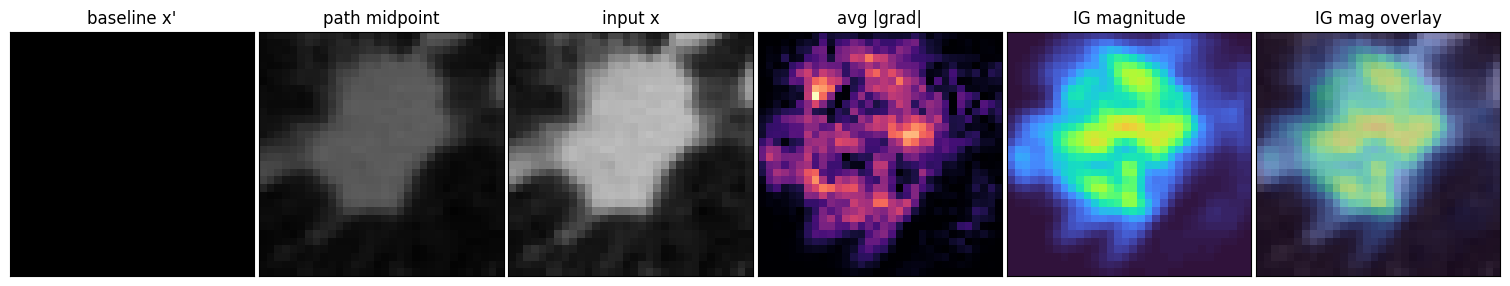

In [13]:
ig_steps = 12  # Use a small number for interactive notebook speed.
baseline_ig = torch.zeros_like(image)  # Use a zero CT patch as the baseline.
total_input_grad = torch.zeros_like(image)  # Accumulate input gradients along the path.

for alpha in torch.linspace(0, 1, ig_steps + 1, device=device)[1:]:  # Skip alpha=0 because the baseline gradient is often uninformative.
    model.zero_grad(set_to_none=True)  # Clear old gradients.
    path_input = (baseline_ig + alpha * (image - baseline_ig)).detach().requires_grad_(True)  # Interpolate from baseline to input.
    logits_path = model(path_input)  # Forward the interpolated volume.
    input_grad = torch.autograd.grad(score_for_target(logits_path, target), path_input)[0]  # Differentiate target score with respect to input voxels.
    total_input_grad += input_grad  # Accumulate path gradients.

avg_input_grad = total_input_grad / ig_steps  # Average gradients along the path.
ig_attr = (image - baseline_ig) * avg_input_grad  # Scale by input-minus-baseline.
ig_heat = normalize_map(gaussian_blur3d(ig_attr.abs().sum(dim=1, keepdim=True), sigma=0.8))  # Visualize absolute attribution magnitude.
heatmaps["Integrated Gradients"] = ig_heat.detach().cpu()  # Store the output for the final overview.

midpoint = baseline_ig + 0.5 * (image - baseline_ig)  # Show the middle point on the path.
fig, axes = plt.subplots(1, 6, figsize=(15.0, 3.0))  # Show the IG workflow.
axes[0].imshow(volume_slice(baseline_ig.cpu(), z_index), cmap="gray", vmin=0, vmax=1)  # Baseline.
axes[0].set_title("baseline x'")  # Label baseline.
axes[1].imshow(volume_slice(midpoint.cpu(), z_index), cmap="gray", vmin=0, vmax=1)  # Midpoint.
axes[1].set_title("path midpoint")  # Label midpoint.
axes[2].imshow(volume_slice(sample["image"], z_index), cmap="gray", vmin=0, vmax=1)  # Input.
axes[2].set_title("input x")  # Label input.
axes[3].imshow(volume_slice(avg_input_grad.abs().sum(dim=1, keepdim=True).detach().cpu(), z_index), cmap="magma")  # Average gradient magnitude.
axes[3].set_title("avg |grad|")  # Label average gradient magnitude.
axes[4].imshow(volume_slice(ig_heat.cpu(), z_index), cmap="turbo", vmin=0, vmax=1)  # IG magnitude heatmap.
axes[4].set_title("IG magnitude")  # Label IG magnitude.
axes[5].imshow(overlay_heatmap(sample["image"], ig_heat.cpu(), z_index))  # Final overlay.
axes[5].set_title("IG mag overlay")  # Label overlay.
for axis in axes:  # Clean all panels.
    axis.set_xticks([])  # Hide x ticks.
    axis.set_yticks([])  # Hide y ticks.
fig.tight_layout(pad=0.35)  # Reduce whitespace.
display(fig)  # Display the figure.
plt.close(fig)  # Close the figure handle.


## 9. Method 07: Integrated Grad-CAM

Integrated Grad-CAM moves the path-integral idea into feature space. It
compares feature maps from baseline and input, then weights those feature
deltas by path-averaged feature gradients. As with the IG panel, the
rendered heatmap is absolute magnitude rather than signed positive or
negative evidence.

Formula:

$$
L^c = \sum_k \left|\Delta A^k \cdot
\frac{1}{m}\sum_t \frac{\partial y_t^c}{\partial A_t^k}\right|
$$


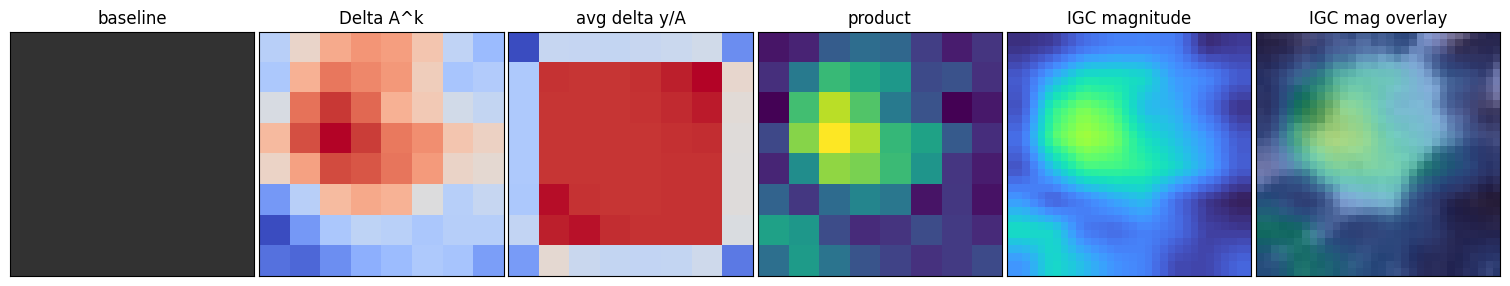

In [14]:
igc_steps = 10  # Keep the feature-path integration interactive.
baseline_igc = torch.ones_like(image) * image.detach().mean(dim=(1, 2, 3, 4), keepdim=True)  # Use a mean-filled baseline.

with torch.no_grad():  # Feature deltas do not require gradients.
    _, input_features = model(image, return_features=True)  # Forward the real input.
    _, baseline_features = model(baseline_igc, return_features=True)  # Forward the baseline input.
    feature_delta = input_features["stage2"] - baseline_features["stage2"]  # Delta A = A(x) - A(x').

total_feature_grad = torch.zeros_like(feature_delta)  # Accumulate feature gradients along the input path.
for alpha in torch.linspace(0, 1, igc_steps + 1, device=device)[1:]:  # Integrate from baseline to input.
    model.zero_grad(set_to_none=True)  # Clear old gradients.
    path_input = (baseline_igc + alpha * (image - baseline_igc)).detach()  # Build one path point.
    logits_path, path_features = model(path_input, return_features=True)  # Forward with feature retention.
    A_path = path_features["stage2"]  # Read stage-2 features at this path point.
    A_path.retain_grad()  # Keep gradients for the feature tensor.
    score_for_target(logits_path, target).backward()  # Backpropagate target logit to features.
    total_feature_grad += A_path.grad  # Accumulate feature gradients.

avg_feature_grad = total_feature_grad / igc_steps  # Average gradients along the path.
igc_contribution = avg_feature_grad * feature_delta  # Weight feature deltas by path-averaged gradients.
igc_feature_map = igc_contribution.abs().sum(dim=1, keepdim=True)  # Sum absolute feature-attribution magnitude across channels.
igc_heat = normalize_map(upsample_to_input(igc_feature_map, image))  # Upsample to input volume size.
heatmaps["Integrated Grad-CAM"] = igc_heat.detach().cpu()  # Store the output for the final overview.

channel_index = int(igc_contribution.flatten(2).abs().mean(dim=2).squeeze(0).argmax().item())  # Pick a visible channel.
feature_z = round(z_index * (feature_delta.shape[-3] - 1) / (image.shape[-3] - 1))  # Map input z to feature z.

fig, axes = plt.subplots(1, 6, figsize=(15.0, 3.0))  # Show the Integrated Grad-CAM workflow.
axes[0].imshow(volume_slice(baseline_igc.cpu(), z_index), cmap="gray", vmin=0, vmax=1)  # Baseline input.
axes[0].set_title("baseline")  # Label baseline.
axes[1].imshow(volume_slice(feature_delta[0, channel_index], feature_z).detach().cpu(), cmap="coolwarm")  # Feature delta.
axes[1].set_title("Delta A^k")  # Label feature delta.
axes[2].imshow(volume_slice(avg_feature_grad[0, channel_index], feature_z).detach().cpu(), cmap="coolwarm")  # Average feature gradient.
axes[2].set_title("avg delta y/A")  # Label path-averaged gradient.
axes[3].imshow(volume_slice(igc_contribution[0, channel_index].abs(), feature_z).detach().cpu(), cmap="viridis")  # Feature product.
axes[3].set_title("product")  # Label product.
axes[4].imshow(volume_slice(igc_heat.cpu(), z_index), cmap="turbo", vmin=0, vmax=1)  # Integrated Grad-CAM magnitude heatmap.
axes[4].set_title("IGC magnitude")  # Label heatmap.
axes[5].imshow(overlay_heatmap(sample["image"], igc_heat.cpu(), z_index))  # Final overlay.
axes[5].set_title("IGC mag overlay")  # Label overlay.
for axis in axes:  # Clean all panels.
    axis.set_xticks([])  # Hide x ticks.
    axis.set_yticks([])  # Hide y ticks.
fig.tight_layout(pad=0.35)  # Reduce whitespace.
display(fig)  # Display the figure.
plt.close(fig)  # Close the figure handle.


## 10. Final Overview: Reuse the Step Outputs

This final figure does not recompute the methods. It reuses the heatmaps
stored in previous cells and places them next to the input and tumour
mask. It first checks that every method cell has run, which prevents an
incomplete overview from being mistaken for the full comparison.


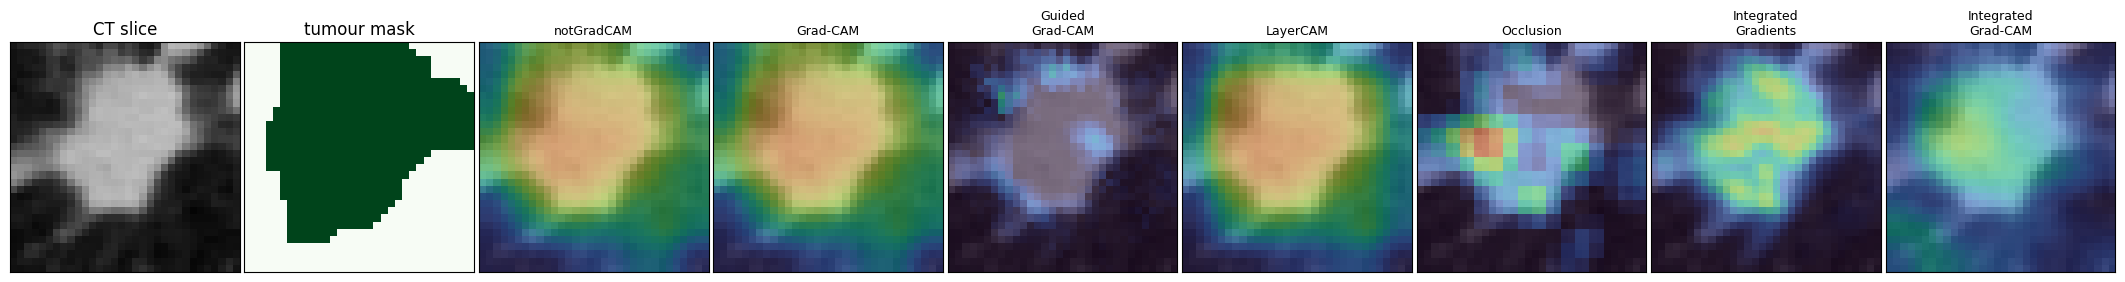

In [15]:
expected_heatmaps = [  # Required method outputs in the same order as the PPT.
    "notGradCAM",
    "Grad-CAM",
    "Guided Grad-CAM",
    "LayerCAM",
    "Occlusion",
    "Integrated Gradients",
    "Integrated Grad-CAM",
]
missing = [name for name in expected_heatmaps if name not in heatmaps]  # Detect skipped method cells.
if missing:  # Stop instead of silently rendering an incomplete overview.
    raise RuntimeError(f"Run previous method cells first. Missing: {missing}")

fig, axes = plt.subplots(1, len(expected_heatmaps) + 2, figsize=(2.35 * (len(expected_heatmaps) + 2), 3.0))  # One row: input, mask, then all methods.
axes[0].imshow(volume_slice(sample["image"], z_index), cmap="gray", vmin=0, vmax=1)  # Input CT.
axes[0].set_title("CT slice")  # Label input.
axes[1].imshow(volume_slice(sample["mask"], z_index), cmap="Greens", vmin=0, vmax=1)  # Tumour mask.
axes[1].set_title("tumour mask")  # Label mask.

for axis, method_name in zip(axes[2:], expected_heatmaps, strict=True):  # Reuse heatmaps computed above.
    heatmap = heatmaps[method_name]  # Read the already-computed method output.
    axis.imshow(overlay_heatmap(sample["image"], heatmap, z_index))  # Draw each method overlay.
    axis.set_title(method_name.replace(" ", "\n"), fontsize=9)  # Label each method.

for axis in axes:  # Clean all panels.
    axis.set_xticks([])  # Hide x ticks.
    axis.set_yticks([])  # Hide y ticks.
fig.tight_layout(pad=0.35)  # Reduce whitespace.
display(fig)  # Display the final overview.
plt.close(fig)  # Close the figure handle.


## 11. Optional Quantitative Sanity Check

The visual outputs above are the main teaching artifact. This optional
cell computes mask-based metrics over several positive test patches.


In [16]:
score_dataset = RealCtDataset(cache_path, split="test", limit=8, positive_only=True)  # Use eight positive test patches.
scores = score_real_ct_attributions(model, score_dataset, device, methods=method_order)  # Score the seven deck methods.
score_path.parent.mkdir(parents=True, exist_ok=True)  # Ensure the output directory exists.
score_path.write_text(json.dumps(scores, indent=2))  # Save the score JSON for reproducibility.
print(json.dumps(scores, indent=2))  # Print the metrics in the notebook.


{
  "notgradcam": {
    "mass_in_gt": 0.26896946877241135,
    "inside_outside_ratio": 2.088215693831444,
    "pointing_acc": 0.5
  },
  "gradcam": {
    "mass_in_gt": 0.27219651453197,
    "inside_outside_ratio": 2.1218371503055096,
    "pointing_acc": 0.5
  },
  "guided_gradcam": {
    "mass_in_gt": 0.3867542129009962,
    "inside_outside_ratio": 4.953760102391243,
    "pointing_acc": 0.625
  },
  "layercam": {
    "mass_in_gt": 0.29077211022377014,
    "inside_outside_ratio": 2.260847046971321,
    "pointing_acc": 0.5
  },
  "occlusion": {
    "mass_in_gt": 0.37057035975158215,
    "inside_outside_ratio": 3.609054859727621,
    "pointing_acc": 0.25
  },
  "integrated_gradients": {
    "mass_in_gt": 0.4949503317475319,
    "inside_outside_ratio": 5.837108254432678,
    "pointing_acc": 0.5
  },
  "integrated_gradcam": {
    "mass_in_gt": 0.24427204066887498,
    "inside_outside_ratio": 1.4746976345777512,
    "pointing_acc": 0.25
  }
}
